# Dem4Cli v2 development

1. New population data gridded - done > integrate into S2S
2. new masks for countries / for life expectancy > TODO
3. new cohort size data - doing

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 80)
%matplotlib inline 

sys.path.append('..')

from population_demographics_v2 import * 

## 1. load new cohort size data

### a) see old data

In [5]:
flags['version'] = 1
dir_cohortsizes = os.path.join(script_dir, 'data/cohort-sizes/WCDE/')
ssp=2

df_cohort_sizes, ages, years = load_cohort_sizes(dir_cohortsizes)


In [3]:
df_cohort_sizes

,2_1950,2_1955,2_1960,2_1965,2_1970,2_1975,2_1980,2_1985,2_1990,2_1995,...,102_2055,102_2060,102_2065,102_2070,102_2075,102_2080,102_2085,102_2090,102_2095,102_2100
Area,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1291.6,1355.1,1539.5,1762.1,2025.6,2326.7,2484.4,2276.9,2377.9,3325.5,...,0.2,0.2,0.3,0.4,0.5,0.7,0.9,1.1,1.6,2.4
Albania,180.8,222.5,272.9,309.7,312.3,324.8,335.2,355.5,388.5,334.4,...,3.2,5.5,8.0,9.7,11.8,14.7,19.1,20.3,24.7,35.4
Algeria,1403.1,1830.6,2081.8,2398.0,2692.6,3086.2,3528.0,3893.8,3994.2,3734.3,...,15.7,23.0,35.4,52.8,78.8,123.7,179.8,235.8,281.4,297.1
Angola,739.2,1023.5,1095.3,1196.5,1298.7,1515.1,1810.3,2122.6,2438.5,2799.6,...,0.4,0.5,0.6,0.8,1.1,1.5,2.1,3.0,4.2,6.1
Antigua and Barbuda,6.6,8.4,8.9,9.2,9.9,9.3,7.3,7.2,7.4,6.8,...,0.0,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.3,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Western Sahara,2.4,3.3,5.4,8.7,13.2,13.3,23.0,29.2,31.8,34.6,...,0.0,0.0,0.1,0.1,0.2,0.3,0.4,0.5,0.7,0.9
World,338387.2,405612.1,432642.8,480601.0,523700.8,543302.0,548178.6,592792.3,644867.3,623061.1,...,5799.9,7789.0,10822.7,14499.7,18443.9,22134.8,28115.2,36321.0,42244.2,48218.6
Yemen,770.2,777.9,860.3,978.0,1173.4,1348.4,1709.7,2115.3,2603.1,3082.0,...,0.3,0.4,0.5,0.7,1.1,2.1,3.4,5.2,7.8,10.2


In [6]:
filepath = dir_cohortsizes+f'wicdf_ssp{ssp}.csv'
df_raw = pd.read_csv(filepath, header=7) # population is in 000's

# total national population through time (rows = countries with names from WCDE, check they match, columns = years)
df_pop_national = df_raw[(df_raw['Sex'] == 'Both') & (df_raw['Age'] == 'All')][['Area', 'Year', 'Population']].pivot(index="Area", columns="Year", values="Population")


In [ ]:
df_raw # you want it to look like this!

,Area,Year,Age,Sex,ISOCode,Population
0,Afghanistan,1950,All,Both,4,7752.1
1,Afghanistan,1955,All,Both,4,8270.5
2,Afghanistan,1960,All,Both,4,8992.4
3,Afghanistan,1965,All,Both,4,9935.0
4,Afghanistan,1970,All,Both,4,11122.4
...,...,...,...,...,...,...
413287,Zimbabwe,2080,100+,Female,716,1.2
413288,Zimbabwe,2085,100+,Female,716,1.8
413289,Zimbabwe,2090,100+,Female,716,2.6
413290,Zimbabwe,2095,100+,Female,716,3.5


### b) new data

In [10]:
flags

{'version': 1, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [11]:
dir_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/WCDE_v3.2.beta'

In [12]:
filepath_cohortsizes=dir_cohortsizes+'/ssp_basic_drivers_release_3.2.beta_full.xlsx'

In [13]:
pd.read_excel(filepath_cohortsizes, sheet_name=1)

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
0,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 100+,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 15-19,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 20-24,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 25-29,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 30-34,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406882,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,167.817493,202.230159,242.446718,289.227372,344.150188,408.863839,484.958158,574.577244,679.527459,801.530437
406883,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2017/yr,NaN,NaN,NaN,NaN,NaN,...,142.607000,171.850000,206.025000,245.778000,292.450000,347.442000,412.105000,488.261000,577.445000,681.120000
406884,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2010/yr,NaN,NaN,NaN,NaN,NaN,...,7173.363687,8652.728869,10446.998134,12612.926499,15222.120997,18366.588436,22153.943502,26753.568238,32317.872273,39014.010438
406885,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,8073.332338,9738.298355,11757.676253,14195.341521,17131.884994,20670.856635,24933.372446,30110.065103,36372.465515,43908.699720


In [14]:

df = pd.read_excel(filepath_cohortsizes, sheet_name=1)

# 1. Exclude rows where 'region' contains (R<number>)
df = df[~df['Region'].str.contains(r"\(R\d+\)", regex=True, na=False)]

# 2. Keep only:
#    - Exactly "Population"
#    - Or "Population|Male|Age <age>"
#    - Or "Population|Female|Age <age>"
population_pattern = (
    #r"^Population$"  # exactly 'Population'
    r"^Population\|(Male|Female)\|Age\s(\d{1,2}(-\d{1,2})?|100\+)$" # age range
)

df = df[df['Variable'].str.contains(population_pattern, regex=True, na=False)]

In [16]:
df

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
38,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 0-4,million,0.630666,0.633850,0.713825,0.820112,0.949960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 10-14,million,0.405776,0.443287,0.511051,0.525418,0.608655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 100+,million,0.000000,0.000000,0.000000,0.000000,0.000001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 15-19,million,0.353874,0.386877,0.422271,0.493369,0.508750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 20-24,million,0.304909,0.332729,0.363826,0.402941,0.472583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399088,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 75-79,million,NaN,NaN,NaN,NaN,NaN,...,0.143250,0.204322,0.211735,0.242217,0.319896,0.395627,0.438217,0.529094,0.565268,0.594757
399095,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 80-84,million,NaN,NaN,NaN,NaN,NaN,...,0.070287,0.106202,0.155388,0.165164,0.193778,0.263518,0.334017,0.378790,0.467772,0.510505
399102,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 85-89,million,NaN,NaN,NaN,NaN,NaN,...,0.026024,0.042097,0.065886,0.099905,0.110098,0.133990,0.190208,0.250217,0.294268,0.376550
399109,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 90-94,million,NaN,NaN,NaN,NaN,NaN,...,0.007523,0.011178,0.018921,0.031030,0.049368,0.057166,0.073223,0.110432,0.153345,0.190379


In [17]:
# Extract sex and age from Variable
df['sex'] = df['Variable'].str.extract(r"^Population\|(Male|Female)", expand=False)
df['age'] = df['Variable'].str.extract(r"Age\s([\d\+]+(?:-\d+)?)", expand=False)


In [18]:
# Melt year columns to long format
year_cols = [c for c in df.columns if re.match(r"^\d{4}$", str(c))]
df_long = df.melt(
    id_vars=['Region', 'sex', 'age','Scenario'],
    value_vars=year_cols,
    var_name='time',
    value_name='population'
)
df_long['time'] = df_long['time'].astype(int)
df_long['Scenario'] = df_long['Scenario'].replace({'Historical Reference': 'historical'})



In [19]:
df_long

,Region,sex,age,Scenario,time,population
0,Afghanistan,Female,0-4,historical,1950,0.630666
1,Afghanistan,Female,10-14,historical,1950,0.405776
2,Afghanistan,Female,100+,historical,1950,0.000000
3,Afghanistan,Female,15-19,historical,1950,0.353874
4,Afghanistan,Female,20-24,historical,1950,0.304909
...,...,...,...,...,...,...
1623589,Zimbabwe,Male,75-79,SSP5,2100,0.594757
1623590,Zimbabwe,Male,80-84,SSP5,2100,0.510505
1623591,Zimbabwe,Male,85-89,SSP5,2100,0.376550
1623592,Zimbabwe,Male,90-94,SSP5,2100,0.190379


In [20]:
df_long.set_index(['Region', 'time', 'age', 'sex','Scenario'])

population
Region      time age   sex    Scenario              
Afghanistan 1950 0-4   Female historical    0.630666
                 10-14 Female historical    0.405776
                 100+  Female historical    0.000000
                 15-19 Female historical    0.353874
                 20-24 Female historical    0.304909
...                                              ...
Zimbabwe    2100 75-79 Male   SSP5          0.594757
                 80-84 Male   SSP5          0.510505
                 85-89 Male   SSP5          0.376550
                 90-94 Male   SSP5          0.190379
                 95-99 Male   SSP5          0.069001

[1623594 rows x 1 columns]

In [37]:
df_long['age'] = df_long['age'].apply(convert_age_range) + 2 

In [38]:
da = df_long.set_index(['Region', 'time', 'age', 'sex', 'Scenario']).to_xarray()['population']
da

<xarray.DataArray 'population' (Region: 237, time: 31, age: 21, sex: 2,
                                Scenario: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.627210e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.912800e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.500000e-05],
          [         nan,          nan,          nan,          nan,
...
           3.023700e-01,          nan],
          [3.556150e-01, 6.956870e-01, 1.216286e+00, 1.109081e+00,
           3.102040e-01,          nan]],

         ...,

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]],

         [[4.961000e-02, 3.116000e-03, 1.506000e-03, 1.463000e-03,
           4.537400e-02,          nan],
          [1.330400e-02, 8.440000e-04, 2.790000e-04, 2.640000e-04,
           1.161900e-02,          nan]]]]])
Coordinates:
  * Region    (Region) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time      (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age       (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102
  * sex       (sex) object 'Female' 'Male'
  * Scenario  (Scenario) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

In [39]:
da.age

<xarray.DataArray 'age' (age: 21)>
array([  2,   7,  12,  17,  22,  27,  32,  37,  42,  47,  52,  57,  62,  67,
        72,  77,  82,  87,  92,  97, 102])
Coordinates:
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [22]:
da = da.rename({'Region':'country', 'Scenario':'ssp'})
da

<xarray.DataArray 'population' (country: 237, time: 31, age: 21, sex: 2, ssp: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 0.000000e+00],
          [         nan,          nan,          nan,          nan,
                    nan, 0.000000e+00]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.470000e-04],
          [         nan,          nan,          nan,          nan,
...
           4.537400e-02,          nan],
          [1.330400e-02, 8.440000e-04, 2.790000e-04, 2.640000e-04,
           1.161900e-02,          nan]],

         ...,

         [[6.621990e-01, 2.322970e-01, 1.273710e-01, 1.195540e-01,
           5.748720e-01,          nan],
          [4.689500e-01, 1.444020e-01, 6.366200e-02, 5.725400e-02,
           3.765500e-01,          nan]],

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]]]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) object '0-4' '10-14' '100+' ... '85-89' '90-94' '95-99'
  * sex      (sex) object 'Female' 'Male'
  * ssp      (ssp) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

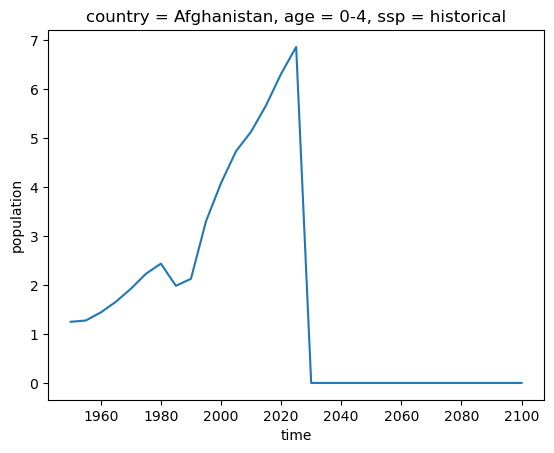

In [23]:
da.sel(ssp='historical', country='Afghanistan',age='0-4').sum(dim='sex').plot()

### test fxn

In [2]:
flags

{'version': 2, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [3]:
dir_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/WCDE_v3.2.beta'

In [4]:
df_cohort_sizes, ages, years = load_cohort_sizes()

In [5]:
df_cohort_sizes

<xarray.DataArray 'population' (country: 237, time: 31, age: 21)>
array([[[1.249598e+00, 9.540010e-01, 8.479810e-01, ..., 1.270000e-04,
         5.000000e-06, 0.000000e+00],
        [1.275876e+00, 1.062110e+00, 9.167520e-01, ..., 1.880000e-04,
         1.000000e-05, 0.000000e+00],
        [1.440271e+00, 1.093636e+00, 1.018713e+00, ..., 3.030000e-04,
         1.700000e-05, 0.000000e+00],
        ...,
        [6.332444e+00, 6.562508e+00, 6.998489e+00, ..., 1.450260e-01,
         2.017500e-02, 1.347000e-03],
        [6.170132e+00, 6.334755e+00, 6.561198e+00, ..., 1.840270e-01,
         2.751600e-02, 1.974000e-03],
        [5.976391e+00, 6.176918e+00, 6.337566e+00, ..., 2.249140e-01,
         3.629300e-02, 2.799000e-03]],

       [[1.839550e-01, 1.559470e-01, 1.424010e-01, ..., 9.080000e-04,
         1.500000e-04, 1.600000e-05],
        [2.309190e-01, 1.743350e-01, 1.537790e-01, ..., 1.680000e-03,
         2.800000e-04, 2.600000e-05],
        [2.890380e-01, 2.228960e-01, 1.746340e-01, ..., 3.002000e-03,
         4.410000e-04, 5.000000e-05],
...
        [2.758125e+00, 2.816799e+00, 2.908411e+00, ..., 7.242500e-02,
         1.265800e-02, 1.233000e-03],
        [2.671221e+00, 2.745646e+00, 2.811111e+00, ..., 9.179400e-02,
         1.618600e-02, 1.592000e-03],
        [2.585075e+00, 2.660460e+00, 2.740787e+00, ..., 1.190690e-01,
         2.111000e-02, 2.100000e-03]],

       [[4.761510e-01, 3.828150e-01, 3.160930e-01, ..., 3.470000e-04,
         5.200000e-05, 4.000000e-06],
        [6.402860e-01, 4.421300e-01, 3.746380e-01, ..., 4.350000e-04,
         5.900000e-05, 3.000000e-06],
        [7.324900e-01, 6.007910e-01, 4.334990e-01, ..., 4.870000e-04,
         7.400000e-05, 5.000000e-06],
        ...,
        [1.386299e+00, 1.451760e+00, 1.494274e+00, ..., 8.475600e-02,
         1.724800e-02, 2.347000e-03],
        [1.328739e+00, 1.379947e+00, 1.449082e+00, ..., 1.114820e-01,
         2.372400e-02, 2.795000e-03],
        [1.271387e+00, 1.324858e+00, 1.379785e+00, ..., 1.318940e-01,
         3.214000e-02, 3.960000e-03]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [6]:
ages

array([  2,   7,  12,  17,  22,  27,  32,  37,  42,  47,  52,  57,  62,
        67,  72,  77,  82,  87,  92,  97, 102])

In [7]:
years

array([1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000,
       2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2055,
       2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100])

In [8]:
da = df_cohort_sizes

In [11]:
da.sel(country='Afghanistan').to_pandas().T

time,1950,1955,1960,1965,1970,1975,1980,1985,1990,1995,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
age,,,,,,,,,,,,,,,,,,,,,
2,1.249598,1.275876,1.440271,1.657766,1.923350,2.229691,2.438529,1.984951,2.128086,3.302788,...,8.217687,8.136818,8.005578,7.744366,7.451600,7.018162,6.565949,6.332444,6.170132,5.976391
7,0.954001,1.062110,1.093636,1.266617,1.476636,1.725049,1.905433,1.590426,1.622083,2.480957,...,8.167990,8.161414,8.088521,7.965643,7.714048,7.430467,7.006311,6.562508,6.334755,6.176918
12,0.847981,0.916752,1.018713,1.062485,1.233340,1.433583,1.582033,1.335124,1.390359,1.984530,...,8.033591,8.128721,8.125283,8.056585,7.938613,7.693243,7.415788,6.998489,6.561198,6.337566
17,0.751730,0.811910,0.876395,0.986516,1.031631,1.194216,1.310253,1.102901,1.166653,1.697424,...,7.804234,7.978761,8.081695,8.087336,8.028349,7.920280,7.685320,7.417550,7.009684,6.580692
22,0.663389,0.708569,0.765037,0.837726,0.946259,0.987882,1.078048,0.892458,0.943803,1.405261,...,7.442725,7.686698,7.864888,7.973113,7.985126,7.934032,7.834237,7.609435,7.351711,6.955146
27,0.568208,0.617233,0.659798,0.723487,0.795823,0.898145,0.883705,0.724457,0.751537,1.126579,...,6.966567,7.308440,7.555248,7.738782,7.853007,7.872464,7.829989,7.739729,7.526605,7.280564
32,0.487298,0.524196,0.570358,0.619671,0.683032,0.751196,0.799741,0.590222,0.608275,0.895322,...,6.367926,6.848340,7.190753,7.441175,7.630061,7.750914,7.777355,7.743173,7.661719,7.459397
37,0.416301,0.444182,0.479103,0.530351,0.579707,0.639376,0.664331,0.530935,0.493473,0.722408,...,5.756779,6.259134,6.737051,7.080722,7.334753,7.529362,7.656542,7.690001,7.663524,7.590224
42,0.353457,0.374167,0.400737,0.440224,0.490679,0.537164,0.559966,0.438479,0.440306,0.583378,...,5.031359,5.649756,6.146863,6.622754,6.967986,7.226474,7.427083,7.561322,7.602230,7.583917


## 1b. interpolate this new data

In [9]:
# test fxn 


da_cohort_size = interpolate_cohortsize_countries(df_cohort_sizes, ages, years)

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 15, Bahrain, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 29, British Virgin Islands, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 32, Burkina Faso, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 39, Central African Republic, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 61, El Salvador, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 65, Eswatini, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 68, Faroe Islands, setting them t

## 2. Load new population data

In [2]:
flags

{'version': 2, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [3]:
dir_population

'/data/brussel/vo/000/bvo00012/data/dataset/COMPASS/v2/01deg'

In [4]:
da_population = load_population()

opening compass - historical
opening compass - ssp2


In [5]:
da_population

<xarray.DataArray 'Population_count' (time: 151, lat: 1800, lon: 3600)>
dask.array<concatenate, shape=(151, 1800, 3600), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.7 179.8 179.9
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
Attributes:
    units:      1
    long_name:  Population_count

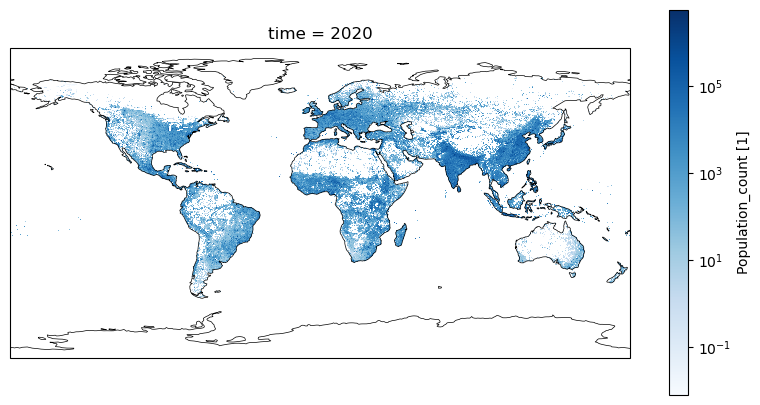

In [12]:
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature



da = da_population.sel(time=2020)

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(10, 5)
)

da.where(da>.000001).plot(norm=LogNorm(), cmap='Blues', ax=ax)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)


In [ ]:
#testing old version still works 


flags['version']=1
dir_population = os.path.join(script_dir, 'data/gridded-pop/') 
da_population = load_population(dir_population)

opening isimip3 - ssp2


In [11]:
da_population

<xarray.DataArray 'total-population' (time: 151, lat: 360, lon: 720)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
Attributes:
    units:          1
    standard_name:  total population